In [1]:
from utils.config import load_config
from analysis.target_analysis import analyze_numeric_feature, analyze_categorical_feature
from analysis.numeric.numeric_summary import build_numeric_summary
from analysis.categorical.categorical_summary import build_categorical_summary
from feature_utils.feature_engineering import replace_with_has_large
from feature_utils.data_cleaning import fill_missing_values, handle_outliers, drop_columns, fill_none_columns, one_hot_encode_columns
import pandas as pd
%matplotlib inline

In [2]:
config = load_config()
train_df = pd.read_csv(config["paths"]["train"])
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


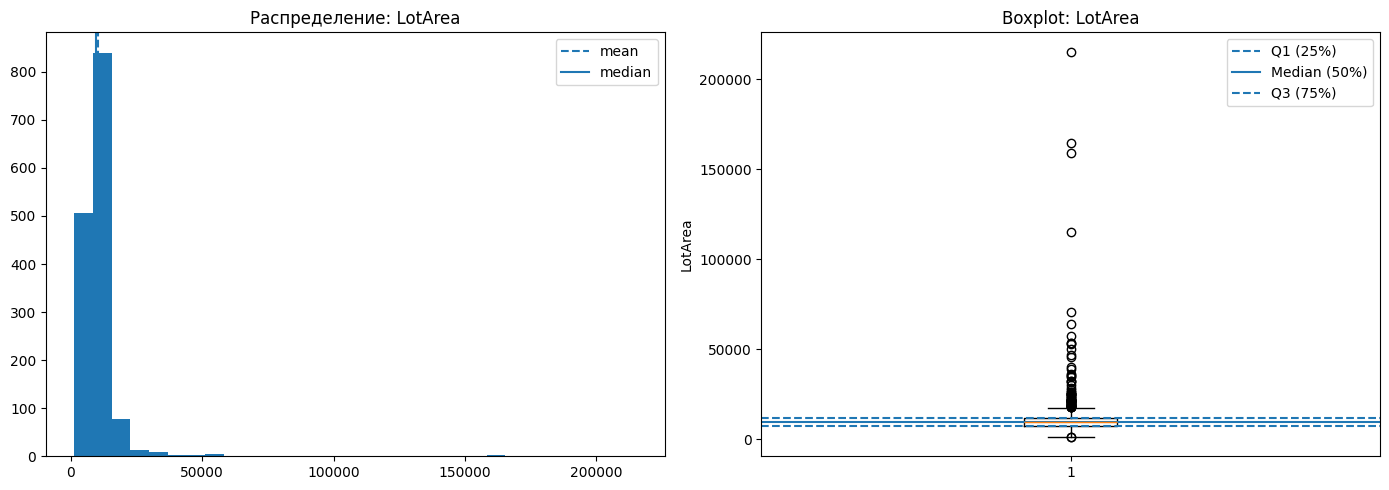

In [3]:
summary = build_numeric_summary(train_df)
summary
stats = analyze_numeric_feature(train_df['LotArea'])

## Feature Engineering: sparse numerical features

В процессе анализа числовых признаков было обнаружено, что некоторые из них имеют сильный перекос распределения (high skew) и медиану, равную 0.

Это означает:
- большинство значений в этих признаках равно 0
- небольшое количество объектов имеет ненулевые (иногда большие) значения

К таким признакам относятся:
- `MiscVal`
- `PoolArea`
- `3SsnPorch`
- `LowQualFinSF`

### Интерпретация

Для данных признаков более важен **факт наличия**, чем конкретное значение.

Например:
- наличие бассейна (`PoolArea > 0`) важнее его площади
- наличие дополнительных построек (`MiscVal > 0`) важнее их стоимости

### Принятое решение

Преобразовать данные признаки в бинарный формат:
- `1` — признак присутствует
- `0` — отсутствует

### Причины такого подхода

- уменьшение влияния выбросов
- упрощение модели
- повышение устойчивости к шуму
- улучшение интерпретируемости

### Результат

Каждый признак заменяется на новый бинарный:
- `Has_MiscVal`
- `Has_PoolArea`
- `Has_3SsnPorch`
- `Has_LowQualFinSF`

Оригинальные признаки удаляются из датасета.

In [4]:
features_sparse = [
    'MiscVal',
    'PoolArea',
    '3SsnPorch',
    'LowQualFinSF'
]

train_df = replace_with_has_large(train_df, features_sparse)

In [5]:
summary = build_numeric_summary(train_df)
summary

,feature,mean,median,std,min,max,missing,missing_%,has_outliers,outlier_%,skew
2,LotFrontage,70.049958,69.0,24.284752,21.0,313.0,True,0.177397,True,0.060274,2.163569
24,GarageYrBlt,1978.506164,1980.0,24.689725,1900.0,2010.0,True,0.055479,False,0.000000,-0.649415
8,MasVnrArea,103.685262,0.0,181.066207,0.0,1600.0,True,0.005479,True,0.065753,2.669084
3,LotArea,10516.828082,9478.5,9981.264932,1300.0,215245.0,False,0.000000,True,0.047260,12.207688
1,MSSubClass,56.897260,50.0,42.300571,20.0,190.0,False,0.000000,True,0.070548,1.407657
0,Id,730.500000,730.5,421.610009,1.0,1460.0,False,0.000000,False,0.000000,0.000000
5,OverallCond,5.575342,5.0,1.112799,1.0,9.0,False,0.000000,True,0.085616,0.693067
4,OverallQual,6.099315,6.0,1.382997,1.0,10.0,False,0.000000,True,0.001370,0.216944
7,YearRemodAdd,1984.865753,1994.0,20.645407,1950.0,2010.0,False,0.000000,False,0.000000,-0.503562
6,YearBuilt,1971.267808,1973.0,30.202904,1872.0,2010.0,False,0.000000,True,0.004795,-0.613461


# Обработка пропусков (Missing Values)

## 📊 Анализ данных

В ходе EDA были найдены признаки с пропусками:

| Feature        | Missing % | Skew   | Outliers |
|---------------|----------|--------|----------|
| LotFrontage   | 17.7%    | 2.16   | ✅       |
| GarageYrBlt   | 5.5%     | -0.64  | ❌       |
| MasVnrArea    | 0.5%     | 2.66   | ✅       |

---

## Подход к заполнению

При выборе стратегии использовались следующие правила:

1. Если распределение **смещено (skew > 1)** → используем **median**
2. Если распределение близко к нормальному → можно использовать **mean**
3. Если есть **выбросы** → median предпочтительнее
4. Если признак имеет **смысловую интерпретацию (например, 0 = отсутствие)** → важно учитывать это

In [6]:
df = fill_missing_values(
    train_df,
    columns=["LotFrontage", "GarageYrBlt", "MasVnrArea"],
    strategy="median",
)

In [7]:
summary = build_numeric_summary(train_df)
summary

,feature,mean,median,std,min,max,missing,missing_%,has_outliers,outlier_%,skew
0,Id,730.500000,730.5,421.610009,1.0,1460.0,False,0.0,False,0.000000,0.000000
1,MSSubClass,56.897260,50.0,42.300571,20.0,190.0,False,0.0,True,0.070548,1.407657
2,LotFrontage,69.863699,69.0,22.027677,21.0,313.0,False,0.0,True,0.072603,2.409147
3,LotArea,10516.828082,9478.5,9981.264932,1300.0,215245.0,False,0.0,True,0.047260,12.207688
4,OverallQual,6.099315,6.0,1.382997,1.0,10.0,False,0.0,True,0.001370,0.216944
5,OverallCond,5.575342,5.0,1.112799,1.0,9.0,False,0.0,True,0.085616,0.693067
6,YearBuilt,1971.267808,1973.0,30.202904,1872.0,2010.0,False,0.0,True,0.004795,-0.613461
7,YearRemodAdd,1984.865753,1994.0,20.645407,1950.0,2010.0,False,0.0,False,0.000000,-0.503562
8,MasVnrArea,103.117123,0.0,180.731373,0.0,1600.0,False,0.0,True,0.067123,2.677616
9,BsmtFinSF1,443.639726,383.5,456.098091,0.0,5644.0,False,0.0,True,0.004795,1.685503


# Обработка выбросов (Outliers)

## Анализ данных

В ходе EDA были проанализированы выбросы с использованием метода IQR.

| Feature           | Outlier % | Skew   |
|------------------|----------|--------|
| LotFrontage      | 7.26%    | 0.47   |
| LotArea          | 4.73%    | 2.45   |
| MasVnrArea       | 6.71%    | 2.04   |
| BsmtFinSF1       | 0.48%    | 1.69   |
| BsmtFinSF2       | 11.44%   | 4.25   |
| BsmtUnfSF        | 1.99%    | 0.92   |
| TotalBsmtSF      | 4.18%    | 0.24   |
| 1stFlrSF         | 1.37%    | 1.38   |
| 2ndFlrSF         | 0.14%    | 0.81   |
| GrLivArea        | 2.12%    | 0.77   |
| GarageArea       | 1.44%    | 0.18   |
| WoodDeckSF       | 2.19%    | 1.54   |
| OpenPorchSF      | 5.27%    | 2.36   |
| EnclosedPorch    | 14.25%   | 2.75   |
| ScreenPorch      | 7.95%    | 4.12   |

---

## Подход к обработке

При выборе стратегии использовались следующие правила:

1. Если **outlier_% < 1%** → игнорируем
2. Если **1–5%** → обычно игнорируем (если нет сильного skew)
3. Если **5–10%** → применяем **clip (ограничение)**
4. Если **>10%** → обязательно обрабатываем
5. Если **skew > 2** → желательно обработать (даже при малом %)

---

## Выбор стратегии

### Clip (основной метод)

Используется ограничение значений сверху:

```python
value = min(value, quantile_99)
```

In [8]:
outlier_columns = [
    "LotFrontage",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GrLivArea",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "ScreenPorch",
]

train_df = handle_outliers(
    train_df,
    columns=outlier_columns,
    quantile=0.95
)

In [9]:
summary = build_numeric_summary(train_df)
summary

,feature,mean,median,std,min,max,missing,missing_%,has_outliers,outlier_%,skew
0,Id,730.500000,730.5,421.610009,1.0,1460.00,False,0.0,False,0.000000,0.000000
1,MSSubClass,56.897260,50.0,42.300571,20.0,190.00,False,0.0,True,0.070548,1.407657
2,LotFrontage,68.662329,69.0,17.545564,21.0,104.00,False,0.0,True,0.032877,-0.223712
3,LotArea,9634.192432,9478.5,3565.813127,1300.0,17401.15,False,0.0,True,0.001370,0.170162
4,OverallQual,6.099315,6.0,1.382997,1.0,10.00,False,0.0,True,0.001370,0.216944
5,OverallCond,5.575342,5.0,1.112799,1.0,9.00,False,0.0,True,0.085616,0.693067
6,YearBuilt,1971.267808,1973.0,30.202904,1872.0,2010.00,False,0.0,True,0.004795,-0.613461
7,YearRemodAdd,1984.865753,1994.0,20.645407,1950.0,2010.00,False,0.0,False,0.000000,-0.503562
8,MasVnrArea,92.047945,0.0,140.590668,0.0,456.00,False,0.0,True,0.067123,1.395183
9,BsmtFinSF1,431.089041,383.5,412.214952,0.0,1274.00,False,0.0,False,0.000000,0.541477


In [10]:
summary = build_categorical_summary(train_df)
summary

,feature,missing,missing_%,unique_count,unique_%,top_value,top_value_%,rare_count,rare_%,is_binary,is_high_cardinality
38,PoolQC,True,0.995205,3,0.002055,Gd,0.428571,0,0.000000,False,False
40,MiscFeature,True,0.963014,4,0.002740,Shed,0.907407,1,0.250000,False,False
2,Alley,True,0.937671,2,0.001370,Grvl,0.549451,0,0.000000,True,False
39,Fence,True,0.807534,4,0.002740,MnPrv,0.558719,0,0.000000,False,False
17,MasVnrType,True,0.597260,3,0.002055,BrkFace,0.756803,0,0.000000,False,False
32,FireplaceQu,True,0.472603,5,0.003425,Gd,0.493506,0,0.000000,False,False
33,GarageType,True,0.055479,6,0.004110,Attchd,0.630892,0,0.000000,False,False
35,GarageQual,True,0.055479,5,0.003425,TA,0.950689,0,0.000000,False,False
36,GarageCond,True,0.055479,5,0.003425,TA,0.961566,0,0.000000,False,False
34,GarageFinish,True,0.055479,3,0.002055,Unf,0.438724,0,0.000000,False,False


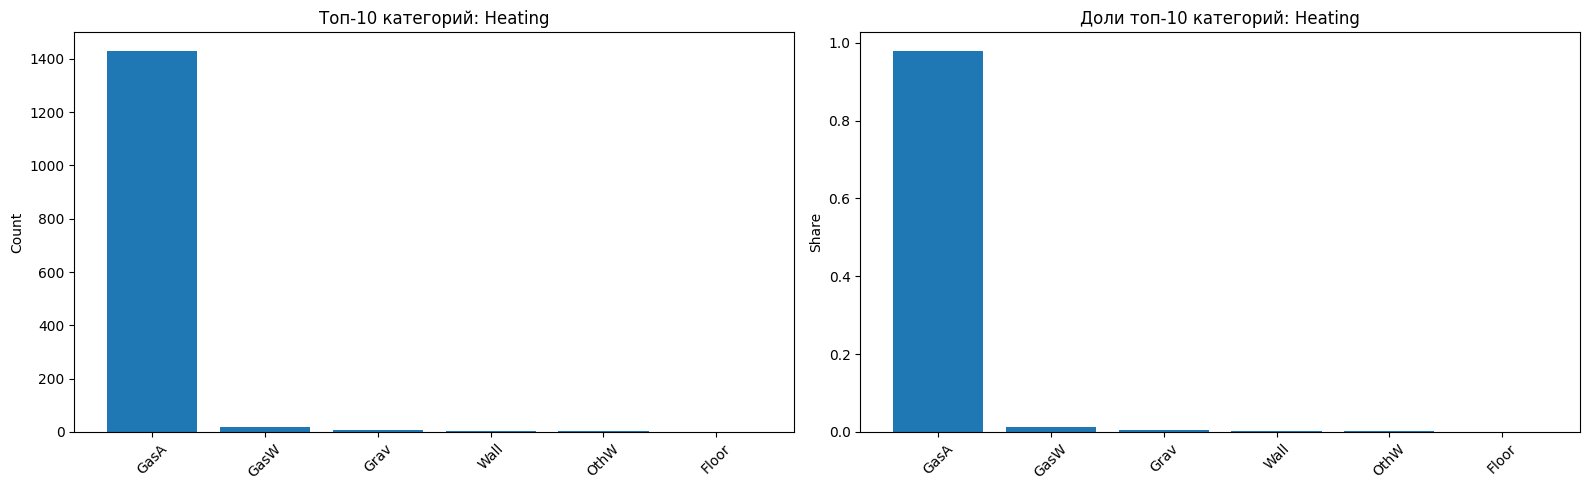

In [11]:
stats = analyze_categorical_feature(train_df['Heating'])

### Удаление малоинформативных признаков
В процессе подготовки данных одним из важных этапов является удаление малоинформативных признаков.


Малоинформативный признак — это такой признак, в котором:
- почти все значения одинаковые
- или одно значение сильно доминирует (например, встречается в 85–99% случаев)

In [12]:
LOW_INFORMATION_COLUMNS = [
    "MiscFeature",
    "GarageQual",
    "GarageCond",
    "BsmtFinType2",
    "BsmtCond",
    "Electrical",
    "Condition1",
    "SaleType",
    "Condition2",
    "RoofMatl",
    "Functional",
    "Heating",
    "ExterCond",
    "LandContour",
    "LandSlope",
    "PavedDrive",
    "Street",
    "Utilities",
    "CentralAir",
]

train_df = drop_columns(train_df, LOW_INFORMATION_COLUMNS)

In [13]:
summary = build_categorical_summary(train_df)
summary

,feature,missing,missing_%,unique_count,unique_%,top_value,top_value_%,rare_count,rare_%,is_binary,is_high_cardinality
21,PoolQC,True,0.995205,3,0.002055,Gd,0.428571,0,0.000,False,False
1,Alley,True,0.937671,2,0.001370,Grvl,0.549451,0,0.000,True,False
22,Fence,True,0.807534,4,0.002740,MnPrv,0.558719,0,0.000,False,False
10,MasVnrType,True,0.597260,3,0.002055,BrkFace,0.756803,0,0.000,False,False
18,FireplaceQu,True,0.472603,5,0.003425,Gd,0.493506,0,0.000,False,False
19,GarageType,True,0.055479,6,0.004110,Attchd,0.630892,0,0.000,False,False
20,GarageFinish,True,0.055479,3,0.002055,Unf,0.438724,0,0.000,False,False
14,BsmtExposure,True,0.026027,4,0.002740,No,0.670183,0,0.000,False,False
15,BsmtFinType1,True,0.025342,6,0.004110,Unf,0.302178,0,0.000,False,False
13,BsmtQual,True,0.025342,4,0.002740,TA,0.456079,0,0.000,False,False


### Обработка пропусков в категориальных признаках

В датасете присутствуют категориальные признаки с пропущенными значениями (`NaN`).
Необходимо корректно обработать их перед обучением модели.

используем порог в 0.4 - то есть, везде где больше 40% пропусков удаляем фичу

In [14]:
HIGH_MISSING_COLUMNS = [
    "PoolQC",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
]
NONE_FILL_COLUMNS = [
    "GarageType",
    "GarageFinish",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtQual",
]

# 1. удалить
train_df = drop_columns(train_df, HIGH_MISSING_COLUMNS)

# 2. заполнить None
train_df = fill_none_columns(train_df, NONE_FILL_COLUMNS)

In [15]:
summary = build_categorical_summary(train_df)
summary

,feature,missing,missing_%,unique_count,unique_%,top_value,top_value_%,rare_count,rare_%,is_binary,is_high_cardinality
3,Neighborhood,False,0.0,25,0.017123,NAmes,0.154110,0,0.000,False,True
8,Exterior2nd,False,0.0,16,0.010959,VinylSd,0.345205,2,0.125,False,False
7,Exterior1st,False,0.0,15,0.010274,VinylSd,0.352740,3,0.200,False,False
5,HouseStyle,False,0.0,8,0.005479,1Story,0.497260,0,0.000,False,False
13,BsmtFinType1,False,0.0,7,0.004795,Unf,0.294521,0,0.000,False,False
16,GarageType,False,0.0,7,0.004795,Attchd,0.595890,0,0.000,False,False
6,RoofStyle,False,0.0,6,0.004110,Gable,0.781507,0,0.000,False,False
10,Foundation,False,0.0,6,0.004110,PConc,0.443151,0,0.000,False,False
18,SaleCondition,False,0.0,6,0.004110,Normal,0.820548,0,0.000,False,False
0,MSZoning,False,0.0,5,0.003425,RL,0.788356,0,0.000,False,False


### Обработка оставшихся категориальных признаков

После:
- удаления малоинформативных признаков
- обработки пропусков

в датасете остались категориальные признаки без пропусков и с достаточной вариативностью.
Все оставшиеся категориальные признаки были преобразованы с помощью One-Hot Encoding.

In [16]:
CATEGORICAL_COLUMNS = [
    "Neighborhood",
    "Exterior1st",
    "Exterior2nd",
    "HouseStyle",
    "GarageType",
    "RoofStyle",
    "Foundation",
    "SaleCondition",
    "MSZoning",
    "LotConfig",
    "BldgType",
    "BsmtQual",
    "BsmtExposure",
    "HeatingQC",
    "LotShape",
    "ExterQual",
    "KitchenQual",
    "GarageFinish",
]

train_df = one_hot_encode_columns(train_df, CATEGORICAL_COLUMNS)

In [17]:
train_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinType1,...,ExterQual_Ex,ExterQual_Fa,KitchenQual_Gd,KitchenQual_TA,KitchenQual_Ex,KitchenQual_Fa,GarageFinish_RFn,GarageFinish_Unf,GarageFinish_Fin,GarageFinish_None
0,1,60,65.0,8450.0,7,5,2003,2003,196.0,GLQ,...,0,0,1,0,0,0,1,0,0,0
1,2,20,80.0,9600.0,6,8,1976,1976,0.0,ALQ,...,0,0,0,1,0,0,1,0,0,0
2,3,60,68.0,11250.0,7,5,2001,2002,162.0,GLQ,...,0,0,1,0,0,0,1,0,0,0
3,4,70,60.0,9550.0,7,5,1915,1970,0.0,ALQ,...,0,0,1,0,0,0,0,1,0,0
4,5,60,84.0,14260.0,8,5,2000,2000,350.0,GLQ,...,0,0,1,0,0,0,1,0,0,0
